Assignment: Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

Task 1: Simple Linear Regression (Single Feature)

1. Data Retrieval and Collection

In [2]:
df = pd.read_csv('Salary_Data.csv')

print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (30, 2)

Column Names: ['YearsExperience', 'Salary']

First 5 rows:


,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [3]:
# Dataset overview
print('Dataset Info:')
df.info()
print('\nStatistical Summary:')
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes

Statistical Summary:


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


2. Data Cleaning

In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Check data types
print('\nData types:')
print(df.dtypes)

# Check for duplicates
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
YearsExperience    0
Salary             0
dtype: int64

Data types:
YearsExperience    float64
Salary               int64
dtype: object

Duplicate rows: 0


In [5]:
# Handle missing values (if any)
if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)
    print('Missing values dropped. New shape:', df.shape)
else:
    print('No missing values found. Dataset is clean.')

# Remove duplicates if any
df.drop_duplicates(inplace=True)
print('Final dataset shape:', df.shape)

No missing values found. Dataset is clean.
Final dataset shape: (30, 2)


3. Feature Design

In [6]:
# Separate feature (X) and label (y)
X = df[['YearsExperience']]   # 2D array required by sklearn
y = df['Salary']

print('Feature shape (X):', X.shape)
print('Label shape (y):', y.shape)
print('\nFeature preview:')
print(X.head())


Feature shape (X): (30, 1)
Label shape (y): (30,)

Feature preview:
   YearsExperience
0              1.1
1              1.3
2              1.5
3              2.0
4              2.2


4. Algorithm Selection

    Choosing Linear Regression.
    Linear Regression is used because it models a continuous target variable using a simple linear relationship between inputs and output:

    ŷ =w⋅x+b

    It is suitable here since the target variable (salary) is continuous and is expected to increase approximately with years of experience. The model is also simple, interpretable, and efficient, making it a good fit for a small and clean dataset.

5. Loss Function Selection
    
    Using Mean Squared Error (MSE). Mean Squared Error (MSE) measures the average of the squared differences between the actual values and the predicted values. It shows how far the model’s predictions are from the true values, with larger errors penalized more heavily.
    
    MSE = (1/n) · Σ(yᵢ - ŷᵢ)²

6. Model Learning (Training)

In [7]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print('\n Learned Parameters ')
print(f'Coefficient (slope)  : {model.coef_[0]:,.2f}')
print(f'Intercept            : {model.intercept_:,.2f}')

Training samples: 24
Testing samples : 6

 Learned Parameters 
Coefficient (slope)  : 9,423.82
Intercept            : 25,321.58


How parameters are learned:

In Linear Regression, the model learns the best values of w (weight) and b (bias) by minimizing the Mean Squared Error (MSE). This can be done either through a direct mathematical solution (Normal Equation) or an iterative approach like Gradient Descent. In practice, tools like sklearn typically use an optimized closed-form method for small datasets.

Interpretation of parameters:

Coefficient (w): Represents how much the salary is expected to increase for each additional year of experience.
Intercept (b): Represents the estimated starting salary when years of experience is zero.

7. Model Evaluation

In [8]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=== Model Evaluation ===')
print(f'Mean Squared Error  (MSE) : {mse:,.2f}')
print(f'Root Mean Sq. Error (RMSE): {rmse:,.2f}')
print(f'Mean Absolute Error (MAE) : {mae:,.2f}')
print(f'R² Score                  : {r2:.4f}')

=== Model Evaluation ===
Mean Squared Error  (MSE) : 49,830,096.86
Root Mean Sq. Error (RMSE): 7,059.04
Mean Absolute Error (MAE) : 6,286.45
R² Score                  : 0.9024


The model performs well overall, with an R² score of 0.9024, meaning it explains about 90% of the variation in salary. The error values show that predictions are generally close to actual salaries, with an average error of around 6–7 thousand (MAE and RMSE). Overall, this indicates a strong and reliable linear regression model with good predictive accuracy.

Visualization

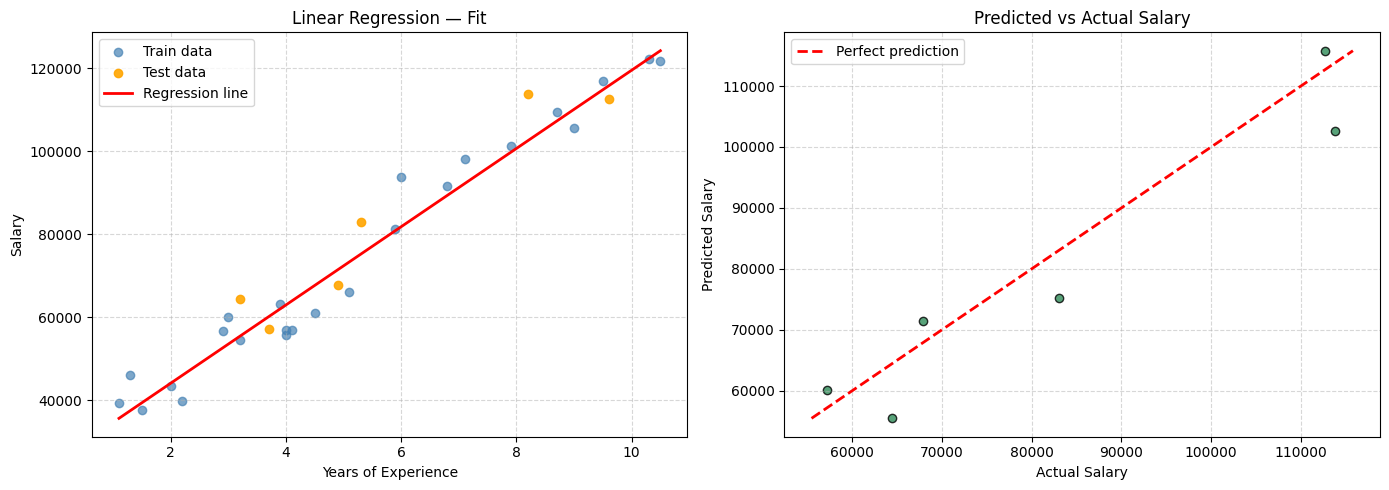

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression line
axes[0].scatter(X_train, y_train, color='steelblue', alpha=0.7, label='Train data')
axes[0].scatter(X_test,  y_test,  color='orange',    alpha=0.9, label='Test data')
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
axes[0].plot(x_line, model.predict(x_line), color='red', linewidth=2, label='Regression line')
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Salary')
axes[0].set_title('Linear Regression — Fit')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Predicted vs Actual
axes[1].scatter(y_test, y_pred, color='seagreen', alpha=0.8, edgecolors='black')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Salary')
axes[1].set_ylabel('Predicted Salary')
axes[1].set_title('Predicted vs Actual Salary')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Discussion

This linear regression model performs strongly on the dataset because salary increases in a near-linear way with years of experience. The high R² value shows that most of the variation in salary can be explained by this single feature.

Limitations:
The model only uses one variable, while real-world salary depends on multiple factors. It is also restricted to linear patterns, so it cannot model more complex relationships. Since the dataset is small, the results may not fully generalize to new data.

Conclusion

This assignment help me understand and remember the complete Machine Learning (ML) pipeline by applying it step-by-step to a Linear Regression problem.The regression line, along with the predicted versus actual values, suggests that the model captures the overall trend in the data quite effectively. The close alignment between predictions and true values indicates a generally good fit.

However, for more reliable real-world performance, the model could be improved by including additional relevant features.

